In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [4]:
# Looking for number of rows and columns
df.shape

(5000, 13)

In [5]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [6]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [9]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

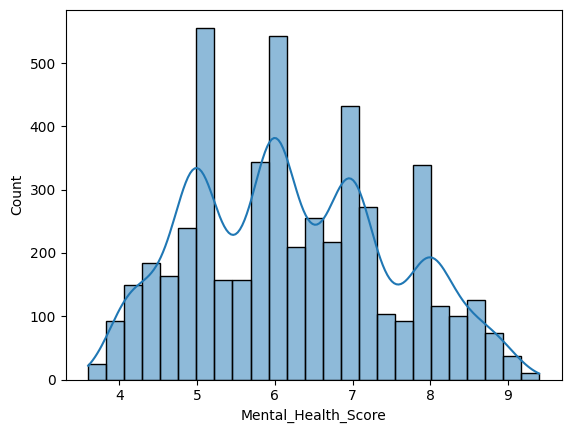

In [10]:
# Exploratory Data Analysis (EDA)
# 1.istribution of the target(Mental Health Score)
sns.histplot(df['Mental_Health_Score'], kde=True)

<Axes: >

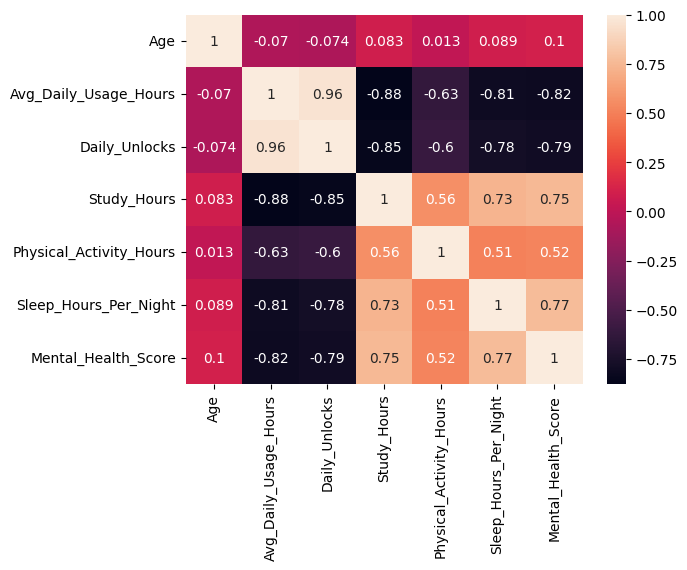

In [11]:
#1.1 Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [12]:
# 1.3 Stress Level vs Mental Health Score
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

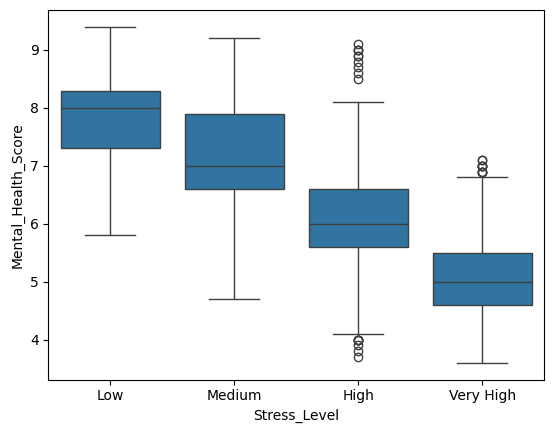

In [13]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order)

In [14]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

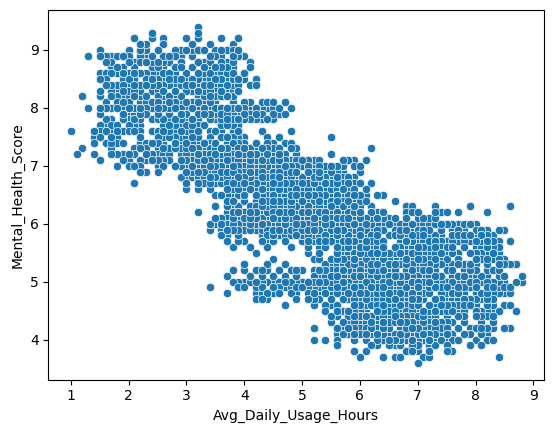

In [15]:
# 1.4 Daily Usage Hours vs Mental Health Score
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

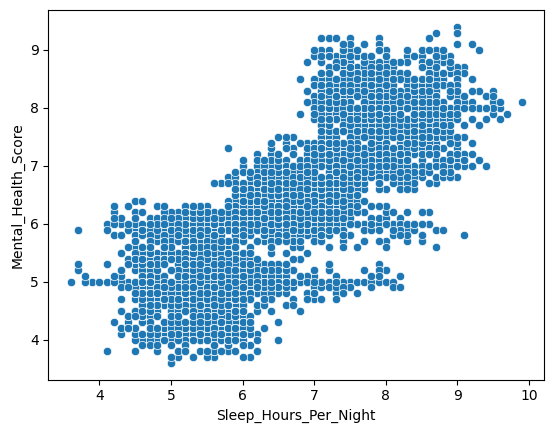

In [16]:
# 1.5 Sleep Hours vs Mental_Health_Score
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)

In [17]:
# 1.6 Most Used Platform (Count)
platform_counts = df['Most_Used_Platform'].value_counts()
platform_counts


Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

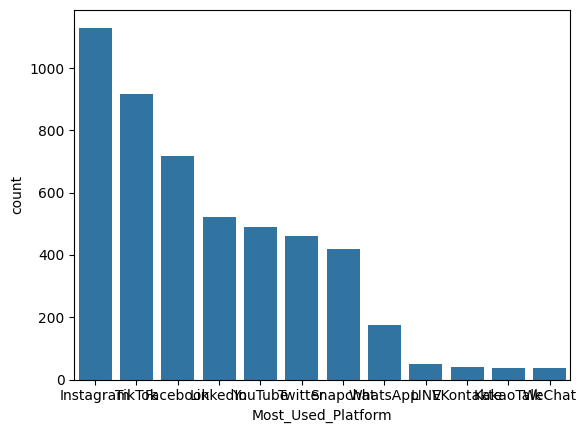

In [18]:
sns.countplot(x=df['Most_Used_Platform'], order=df['Most_Used_Platform'].value_counts().index) 

Checking Outliers


In [19]:
num_features = df.select_dtypes(include='number') #int64 or float64
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


Data Cleaning


In [20]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [21]:
#1. To drop duplicates
df = df.drop_duplicates()

#2. Converting negative or unrealistic values to realistic value
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)


Skewness
Skewness is a measure of how lopsided a numeric columns distribution is. A value near 0 means roughly symmetric, a large positive or negative values means the data leans heavily t one sided, with a long tail.

Why it matters: models like linear regression assume features are roughly well-behaved.

In [22]:
nums_cols = df.select_dtypes(include='number')
nums_cols.skew()
# near to 0 -> Centralized (0.02,0.04)
# negative (greater than 0) -> Left Skewed (-1.56)
# Positive (greater than 0) -> Right Skewed (1.256)

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

Feature Engineering


In [23]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [24]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other' 

In [41]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [25]:
df['Grouped_country'] =df['Country'].apply(group_countries)

In [26]:
df['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

Result: we went from 111 raw categories down to 11 manageable ones(10 countries + other).

Train-Test Split


In [27]:
from sklearn.model_selection import train_test_split

skewed_cols =['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks", "Physical_Activity_Hours", "Sleep_Hours_Per_Night"]
ordinal_col = ['Stress_Level']
normal_col = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]

feature_col = skewed_cols + other_numeric_cols + ordinal_col + normal_col
x = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

10. Preprocessing using ColumnTransformer

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#1. Skewed features
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

#2. Numeric features
plain_numeric_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])

#3. Ordinal
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#4. Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

# (konsi_pipeline, konsa_feature)
preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skewed_cols),
    ("Plain_Numeric", plain_numeric_pipeline, other_numeric_cols),
    ("Ordinal", ordinal_pipeline, ordinal_col),
    ("Normal", nominal_pipeline, normal_col)
])

11. Build a Pipeline

12. Model Building

12.1 Baseline: Linear Regression


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regression', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f"Mean Absolute Error: {lr_mae}")

Accuracy of Training 0.7236771199387539
Accuracy of Testing 0.7397944617433019
Mean Absolute Error: 0.5361775634720183


12.2 Random Forest

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random_forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"Mean Absolute Error: {lr_mae}")

Accuracy of Training 0.9808669071711846
Accuracy of Testing 0.8769929126344471
Mean Absolute Error: 0.5361775634720183


12.3 - Hyperparameter Tuning the Random Forest

In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random_forest__n_estimators'     : [100,200,300],
    'random_forest__max_depth'        : [5,10,15],
    'random_forest__min_samples_split': [2,5,10],
    'random_forest__min_samples_leaf' : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_grid,
    n_iter = 10,
    cv = 5,
    scoring = 'r2',
    random_state = 42,
    n_jobs = -1
)    

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_Numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Ph...
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'random_forest__max_depth': [5, 10, 15],
                                        'random_forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random_forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random_forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [32]:
random_search.best_params_

{'random_forest__n_estimators': 200,
 'random_forest__min_samples_split': 10,
 'random_forest__min_samples_leaf': 2,
 'random_forest__max_depth': 15}

In [33]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8572708362218441
MAE Score for random forest after hyperparameter tuning 0.3816614077235575


13. Model Evaluation
Metrics, explained simply:

R² Score — how much of the variation in mental health scores our model explains, from 0 (useless) to 1 (perfect). 0.85 means the model explains 85% of the pattern.

MAE (Mean Absolute Error) — on average, how far off our prediction is, in the original units (score points). Easy to explain to a non-technical person.

RMSE (Root Mean Squared Error) — similar to MAE, but penalizes big mistakes more heavily. Useful for spotting whether a model makes a few very wrong predictions.

Cross-validation R² (from tuning, above) tells us how good the model is across many different train/validation splits — the real, honest test is still the untouched test set below.

In [35]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2 = r2_score(y_test, rf_tuned_preds)

# Create a Dataframe to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.876993     0.980867  0.348574  0.464808
2    Random Forest (tuned)  0.857271     0.935421  0.381661  0.500686


14. Save the Model

Saving the full pipeline means the backend just loads one file and calls .predict() on raw 

In [37]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

Next Steps (part -2)

build a FastAPI backend with Pydantic request validation that loads mental_health_prediction.pkl and exposes a /predict endpoint, then connect a simple fronted then deploy both so this becomes a live, clickable demo.

In [38]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'Grouped_country']